# EDA Parte 2 – `feature_frame.csv`

Este dataset es diferente al de la parte 1: ya no estamos mirando los datos crudos de la empresa, sino un dataset que alguien ha construido específicamente para entrenar un modelo de ML.

La estructura es sencilla: cada fila es un par **(pedido, producto candidato)**:
- `outcome = 1` → ese producto **sí acabó en el pedido**
- `outcome = 0` → ese producto **no se compró** (pero era candidato)

Algo importante: todas las features están calculadas con información **anterior** a la fecha del pedido — sin data leakage.

**Tamaño:** ~2.88 millones de filas × 27 columnas


## 0. Setup


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

DATA_PATH = Path("../data/module_2/box_builder_dataset/feature_frame.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Load the full dataset 
df = pd.read_csv(DATA_PATH, parse_dates=["created_at", "order_date"])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes.to_string()}")


Shape: 2,880,549 rows x 27 columns

Column types:
variant_id                                   int64
product_type                                object
order_id                                     int64
user_id                                      int64
created_at                          datetime64[ns]
order_date                          datetime64[ns]
user_order_seq                               int64
outcome                                    float64
ordered_before                             float64
abandoned_before                           float64
active_snoozed                             float64
set_as_regular                             float64
normalised_price                           float64
discount_pct                               float64
vendor                                      object
global_popularity                          float64
count_adults                               float64
count_children                             float64
count_babies                    

## 1. Checks rápidos

Las preguntas de siempre:
1. ¿Hay nulls?
2. ¿Hay duplicados?
3. ¿Cómo de desbalanceada está la variable objetivo (`outcome`)?
4. ¿Cuántos datos tenemos y en qué rango temporal?


In [2]:
#1.1 Missing values 
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"null_count": null_counts, "null_%": null_pct})
null_summary = null_summary[null_summary["null_count"] > 0].sort_values("null_%", ascending=False)

print("=== 1.1 MISSING VALUES ===")
if null_summary.empty:
    print("  No missing values — dataset is complete.")
else:
    print(null_summary.to_string())

#1.2 Duplicates 
full_dups = df.duplicated().sum()
key_dups  = df.duplicated(subset=["order_id", "variant_id"]).sum()

print("\n=== 1.2 DUPLICATES ===")
print(f"  Fully duplicated rows             : {full_dups:,}")
print(f"  Duplicate (order_id, variant_id)  : {key_dups:,}")
if full_dups == 0 and key_dups == 0:
    print("  No duplicates — each (order, product) pair is unique.")

#1.3 Target variable balance 
print("\n=== 1.3 OUTCOME BALANCE ===")
vc = df["outcome"].value_counts().sort_index()
for k, v in vc.items():
    print(f"  {int(k)} : {v:,}  ({v / len(df) * 100:.2f}%)")
print(f"  Imbalance ratio: {vc[0] / vc[1]:.1f}:1  (negatives per positive)")

#1.4 Temporal range and scale 
print("\n=== 1.4 TEMPORAL RANGE & SCALE ===")
print(f"  order_date  min : {df['order_date'].min().date()}")
print(f"  order_date  max : {df['order_date'].max().date()}")
print(f"  Unique orders   : {df['order_id'].nunique():,}")
print(f"  Unique users    : {df['user_id'].nunique():,}")
print(f"  Unique products : {df['variant_id'].nunique():,}")
print("\nProducts shown as candidates per order (distribution):")
print(df.groupby("order_id")["variant_id"].count().describe().round(1).to_string())


=== 1.1 MISSING VALUES ===
  No missing values — dataset is complete.



=== 1.2 DUPLICATES ===
  Fully duplicated rows             : 0
  Duplicate (order_id, variant_id)  : 0
  No duplicates — each (order, product) pair is unique.

=== 1.3 OUTCOME BALANCE ===
  0 : 2,847,317  (98.85%)
  1 : 33,232  (1.15%)
  Imbalance ratio: 85.7:1  (negatives per positive)

=== 1.4 TEMPORAL RANGE & SCALE ===
  order_date  min : 2020-10-05
  order_date  max : 2021-03-03
  Unique orders   : 3,446
  Unique users    : 1,937
  Unique products : 976

Products shown as candidates per order (distribution):
count   3446.0000
mean     835.9000
std       81.7000
min      608.0000
25%      794.0000
50%      847.0000
75%      885.0000
max      976.0000


### Conclusiones de checks iniciales

| Check | Resultado |
|---|---|
| Valores nulos | **Ninguno**  |
| Duplicados | **Ninguno** — cada par `(order_id, variant_id)` es único |
| Balance del target | **98.85% negativos / 1.15% positivos** → ratio 85.7:1 |
| Rango temporal | Oct 2020 → Mar 2021 (~5 meses) |
| Escala | 3.446 pedidos · 1.937 usuarios · 976 productos |
| Candidatos por pedido | media ~836 productos (mín 608, máx 976) |

No hay nada que corregir.

Lo más llamativo es el desbalanceo de clases: de cada ~86 productos que se ofrecen a un usuario por pedido, solo compra 1. Lo que está pasando es que enseña cientos de productos en cada caja, pero el usuario solo lleva un puñado. Cualquier modelo que entrenemos tendrá que tener en cuenta esto.

También me llama la atención que el número de candidatos por pedido varía bastante (608 a 976). El máximo crece con el tiempo porque el catálogo se amplía, lo que significa que el problema se vuelve progresivamente más difícil (hay más donde elegir y la señal se diluye)

## 2. ¿Qué información tenemos?

Qué representa cada columna:
1. Ver los nombres de todas las columnas y sus estadísticas básicas
2. Clasificarlas en grupos según lo que representan
3. primer vistazo a sus distribuciones


In [3]:
#all column names and their basic stats
print("=== ALL COLUMNS ===")
for col in df.columns:
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    example = df[col].dropna().iloc[0]
    print(f"  {col:<45} dtype={str(dtype):<10}  unique={n_unique:>7,}  example={example}")


=== ALL COLUMNS ===
  variant_id                                    dtype=int64       unique=    976  example=33826472919172


  product_type                                  dtype=object      unique=     62  example=ricepastapulses
  order_id                                      dtype=int64       unique=  3,446  example=2807985930372
  user_id                                       dtype=int64       unique=  1,937  example=3482464092292
  created_at                                    dtype=datetime64[ns]  unique=  3,446  example=2020-10-05 16:46:19
  order_date                                    dtype=datetime64[ns]  unique=    149  example=2020-10-05 00:00:00
  user_order_seq                                dtype=int64       unique=     20  example=3
  outcome                                       dtype=float64     unique=      2  example=0.0
  ordered_before                                dtype=float64     unique=      2  example=0.0
  abandoned_before                              dtype=float64     unique=      2  example=0.0
  active_snoozed                                dtype=float64     unique=      2  ex

  set_as_regular                                dtype=float64     unique=      2  example=0.0
  normalised_price                              dtype=float64     unique=    127  example=0.0810517755489292
  discount_pct                                  dtype=float64     unique=    526  example=0.0535117056856186


  vendor                                        dtype=object      unique=    264  example=clearspring
  global_popularity                             dtype=float64     unique=  5,968  example=0.0
  count_adults                                  dtype=float64     unique=      5  example=2.0
  count_children                                dtype=float64     unique=      4  example=0.0
  count_babies                                  dtype=float64     unique=      2  example=0.0
  count_pets                                    dtype=float64     unique=      5  example=0.0
  people_ex_baby                                dtype=float64     unique=      5  example=2.0
  days_since_purchase_variant_id                dtype=float64     unique=    142  example=33.0


  avg_days_to_buy_variant_id                    dtype=float64     unique=    122  example=42.0
  std_days_to_buy_variant_id                    dtype=float64     unique=    819  example=31.134053301261627
  days_since_purchase_product_type              dtype=float64     unique=    141  example=30.0
  avg_days_to_buy_product_type                  dtype=float64     unique=     26  example=30.0
  std_days_to_buy_product_type                  dtype=float64     unique=     61  example=24.276180060339996


### ¿Qué significa cada columna?

Podemos agrupar las 27 columnas en 5 categorías:

Identificadores y metadatos
| Columna | Qué es |
|---|---|
| `order_id` | ID del pedido |
| `user_id` | ID del usuario |
| `variant_id` | ID del producto |
| `created_at` | Timestamp exacto de creación del pedido |
| `order_date` | Fecha del pedido (sin hora) |

---

Variable objetivo
| Columna | Qué es |
|---|---|
| `outcome` | 1 si el usuario compró este producto en este pedido, 0 si no |

---

Señales de comportamiento previo del usuario con este producto
| Columna | Qué es |
|---|---|
| `ordered_before` | ¿Ha comprado ya este producto alguna vez? (0/1) |
| `abandoned_before` | ¿Lo ha dejado en el carrito sin comprar antes? (0/1) |
| `active_snoozed` | ¿El usuario ha "silenciado" este producto? (0/1) |
| `set_as_regular` | ¿El usuario lo tiene marcado como producto habitual? (0/1) |
| `user_order_seq` | Número de pedido del usuario (1 = primer pedido, 2 = segundo...) |

---

Características del producto
| Columna | Qué es |
|---|---|
| `product_type` | Categoría del producto (62 categorías distintas) |
| `vendor` | Marca o proveedor (264 distintos) |
| `normalised_price` | Precio normalizado del producto |
| `discount_pct` | Porcentaje de descuento aplicado |
| `global_popularity` | Popularidad global del producto entre todos los usuarios |

---

Contexto del hogar del usuario
| Columna | Qué es |
|---|---|
| `count_adults` | Número de adultos en el hogar |
| `count_children` | Número de niños |
| `count_babies` | Número de bebés |
| `count_pets` | Número de mascotas |
| `people_ex_baby` | Total de personas excluyendo bebés |

---

Patrones temporales de compra
| Columna | Qué es |
|---|---|
| `days_since_purchase_variant_id` | Días desde la última vez que compró **este producto** |
| `avg_days_to_buy_variant_id` | Promedio de días entre compras de **este producto** |
| `std_days_to_buy_variant_id` | Variabilidad en esos intervalos (cuánto varía la frecuencia) |
| `days_since_purchase_product_type` | Días desde la última vez que compró algo de **esta categoría** |
| `avg_days_to_buy_product_type` | Promedio de días entre compras de **esta categoría** |
| `std_days_to_buy_product_type` | Variabilidad en esos intervalos de categoría |

---

Intuición: las features más predictivas serán probablemente `set_as_regular`, `ordered_before` y `days_since_purchase_variant_id`. Si alguien ya compró un producto antes y lo tiene como "regular", es muy probable que lo vuelva a comprar.


## 3. ¿Qué features separan mejor las compras de las no-compras?

La pregunta más importante del EDA es: ¿qué diferencia a un producto que acaba siendo comprado de uno que no?

Para las features binarias (0/1), miramos la **tasa de compra** cuando la feature es 1 vs cuando es 0.
Para las features numéricas, comparamos la **media** entre los dos grupos (outcome=0 vs outcome=1).


In [4]:
#Binary features: purchase rate when flag = 1 vs flag = 0
binary_features = ["ordered_before", "abandoned_before", "active_snoozed", "set_as_regular"]

print("=== BINARY FEATURES: purchase rate (outcome=1) ===\n")
print(f"  {'Feature':<30} {'Rate when 0':>12}  {'Rate when 1':>12}  {'Lift':>8}")
print("  " + "-" * 70)

for feat in binary_features:
    rate_0 = df[df[feat] == 0]["outcome"].mean()
    rate_1 = df[df[feat] == 1]["outcome"].mean()
    lift   = rate_1 / rate_0 if rate_0 > 0 else float("inf")
    print(f"  {feat:<30} {rate_0:>11.2%}  {rate_1:>11.2%}  {lift:>7.1f}x")

#Numerical features: mean by outcome 
numerical_features = [
    "normalised_price", "discount_pct", "global_popularity",
    "user_order_seq",
    "days_since_purchase_variant_id", "avg_days_to_buy_variant_id",
    "days_since_purchase_product_type", "avg_days_to_buy_product_type",
]

print("\n=== NUMERICAL FEATURES: mean by outcome ===\n")
print(f"  {'Feature':<40} {'Mean (not bought)':>18}  {'Mean (bought)':>14}")
print("  " + "-" * 78)

for feat in numerical_features:
    mean_0 = df[df["outcome"] == 0][feat].mean()
    mean_1 = df[df["outcome"] == 1][feat].mean()
    print(f"  {feat:<40} {mean_0:>18.4f}  {mean_1:>14.4f}")


=== BINARY FEATURES: purchase rate (outcome=1) ===

  Feature                         Rate when 0   Rate when 1      Lift
  ----------------------------------------------------------------------


  ordered_before                       0.82%       16.50%     20.1x


  abandoned_before                     1.11%       71.79%     64.6x


  active_snoozed                       1.13%       11.35%     10.0x


  set_as_regular                       1.07%       24.97%     23.4x

=== NUMERICAL FEATURES: mean by outcome ===

  Feature                                   Mean (not bought)   Mean (bought)
  ------------------------------------------------------------------------------


...

  user_order_seq                                       3.2870          3.4909


  days_since_purchase_variant_id                      33.1205         33.9125


  avg_days_to_buy_variant_id                          35.2601         33.2850


  days_since_purchase_product_type                    31.4212         32.6305


  avg_days_to_buy_product_type                        30.8956         30.2482


### Conclusiones

Lo más sorprendente para mí es `abandoned_before`: un lift de 64.6x es enorme. Que alguien haya puesto un producto en el carrito y no lo haya comprado es la señal más fuerte de que lo va a querer en el siguiente pedido. Probablemente lo dejó porque estaba dudando, no porque no lo quisiera.

`set_as_regular` y `ordered_before` también son muy fuertes (23x y 20x), lo que confirma la intuición: el historial propio del usuario con ese producto concreto es clave.

Algo que me resulta curioso es `active_snoozed` con un lift de 10x. Si el usuario ha silenciado un producto, ¿no debería comprarlo menos? A lo mejor es que snoozed significa "ya lo tengo en casa, no me lo enseñes ahora". Es decir, es un producto que sí usa, pero que de momento ya tiene. Eso explicaría que la tasa de compra futura siga siendo alta.

Entre las numéricas, `global_popularity` es la más diferenciadora: los productos comprados tienen una popularidad media 3.4x mayor. El descuento prácticamente no discrimina (0.186 vs 0.189), los usuarios de esta plataforma no parecen comprar principalmente por precio, lo que encaja con el perfil del usuario eco-friendly de la parte 1.

Las features temporales (`days_since_purchase`) muestran diferencias muy pequeñas como promedio. Probablemente tienen efectos no lineales: si llevas 30 días sin comprar algo que sueles pedir cada mes, la probabilidad sube mucho, pero como diferencia de medias no se captura bien.


## 4. Evolución temporal

Tenemos datos de octubre 2020 a marzo 2021. Vamos a mirar:
- ¿Cuántos pedidos se hacen por semana? ¿El negocio crecía?
- ¿La tasa de compra (`outcome`) se mantiene estable o varía con el tiempo?
- ¿El catálogo de productos disponibles crece con el tiempo?

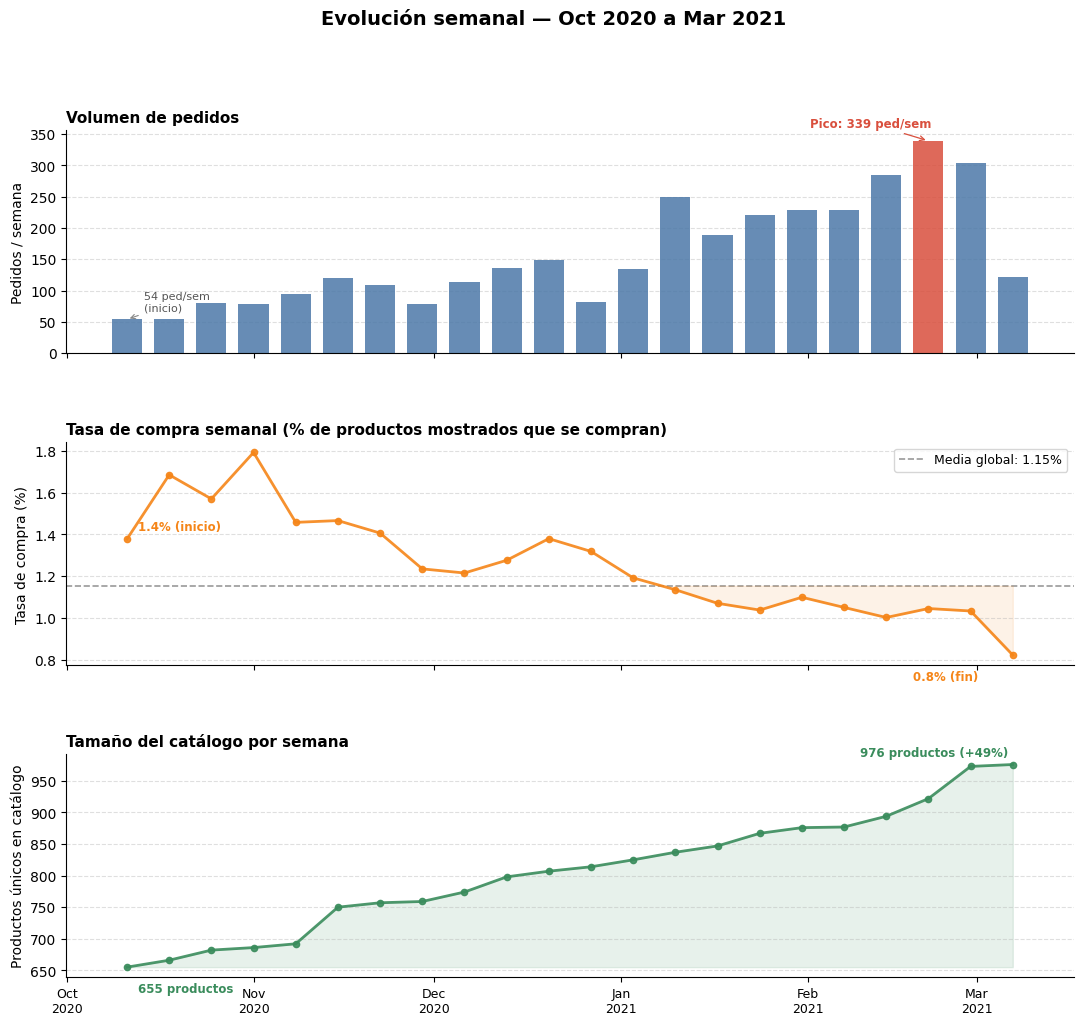

Plot saved.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# Weekly aggregation: one row per week
weekly = (
    df.groupby(pd.Grouper(key="order_date", freq="W"))
    .agg(
        n_orders    =("order_id",  "nunique"),
        n_users     =("user_id",   "nunique"),
        n_products  =("variant_id","nunique"),
        outcome_rate=("outcome",   "mean"),
    )
    .reset_index()
)

# Color palette
COL_ORDERS = "#4C78A8"
COL_RATE   = "#F58518"
COL_CAT    = "#3A8C5C"
COL_AVG    = "#999999"

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle("Evolución semanal — Oct 2020 a Mar 2021", fontsize=14, fontweight="bold", y=0.99)

# --- Panel 1: orders per week ---
peak_idx    = weekly["n_orders"].idxmax()
colors_bars = [COL_ORDERS] * len(weekly)
colors_bars[peak_idx] = "#D94F3D"   # highlight peak in red

axes[0].bar(weekly["order_date"], weekly["n_orders"],
            color=colors_bars, width=5, alpha=0.85, zorder=2)
axes[0].set_ylabel("Pedidos / semana", fontsize=10)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_title("Volumen de pedidos", fontsize=11, fontweight="bold", loc="left", pad=6)

first_row = weekly.iloc[0]
peak_row  = weekly.loc[peak_idx]

axes[0].annotate(f"{first_row.n_orders} ped/sem\n(inicio)",
                 xy=(first_row.order_date, first_row.n_orders),
                 xytext=(12, 6), textcoords="offset points",
                 fontsize=8, color="#555555",
                 arrowprops=dict(arrowstyle="->", color="#888888", lw=0.8))
axes[0].annotate(f"Pico: {peak_row.n_orders} ped/sem",
                 xy=(peak_row.order_date, peak_row.n_orders),
                 xytext=(-85, 10), textcoords="offset points",
                 fontsize=8.5, color="#D94F3D", fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="#D94F3D", lw=0.9))

# --- Panel 2: outcome rate per week ---
overall_rate = df["outcome"].mean() * 100
axes[1].plot(weekly["order_date"], weekly["outcome_rate"] * 100,
             color=COL_RATE, marker="o", linewidth=2, markersize=4.5,
             alpha=0.9, zorder=2)
axes[1].axhline(overall_rate, color=COL_AVG, linestyle="--", linewidth=1.2,
                label=f"Media global: {overall_rate:.2f}%", zorder=1)

# Shade area below the global mean
axes[1].fill_between(weekly["order_date"], weekly["outcome_rate"] * 100, overall_rate,
                     where=weekly["outcome_rate"] * 100 < overall_rate,
                     alpha=0.10, color=COL_RATE)

start_rate = weekly["outcome_rate"].iloc[0]  * 100
end_rate   = weekly["outcome_rate"].iloc[-1] * 100
axes[1].annotate(f"{start_rate:.1f}% (inicio)",
                 xy=(weekly["order_date"].iloc[0], start_rate),
                 xytext=(8, 6), textcoords="offset points",
                 fontsize=8.5, color=COL_RATE, fontweight="bold")
axes[1].annotate(f"{end_rate:.1f}% (fin)",
                 xy=(weekly["order_date"].iloc[-1], end_rate),
                 xytext=(-72, -18), textcoords="offset points",
                 fontsize=8.5, color=COL_RATE, fontweight="bold")

axes[1].set_ylabel("Tasa de compra (%)", fontsize=10)
axes[1].set_title("Tasa de compra semanal (% de productos mostrados que se compran)",
                  fontsize=11, fontweight="bold", loc="left", pad=6)
axes[1].legend(fontsize=9, loc="upper right")

# --- Panel 3: unique products in catalogue ---
axes[2].plot(weekly["order_date"], weekly["n_products"],
             color=COL_CAT, marker="o", linewidth=2, markersize=4.5,
             alpha=0.9, zorder=2)
axes[2].fill_between(weekly["order_date"],
                     weekly["n_products"].min(), weekly["n_products"],
                     alpha=0.12, color=COL_CAT)

start_cat = weekly["n_products"].iloc[0]
end_cat   = weekly["n_products"].iloc[-1]
axes[2].annotate(f"{start_cat} productos",
                 xy=(weekly["order_date"].iloc[0], start_cat),
                 xytext=(8, -18), textcoords="offset points",
                 fontsize=8.5, color=COL_CAT, fontweight="bold")
axes[2].annotate(f"{end_cat} productos (+{int((end_cat/start_cat-1)*100)}%)",
                 xy=(weekly["order_date"].iloc[-1], end_cat),
                 xytext=(-110, 6), textcoords="offset points",
                 fontsize=8.5, color=COL_CAT, fontweight="bold")

axes[2].set_ylabel("Productos únicos en catálogo", fontsize=10)
axes[2].set_title("Tamaño del catálogo por semana",
                  fontsize=11, fontweight="bold", loc="left", pad=6)

# X-axis: one label per month, clean format
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), ha="center", fontsize=9)

# Common styling
for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.subplots_adjust(hspace=0.40)
plt.savefig("temporal_evolution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved.")


### Conclusiones de los gráficos

**Volumen de pedidos por semana:**

El negocio creció de forma muy clara: de ~54 pedidos/semana en octubre a un pico de 339 pedidos/semana en febrero 2021. casi 6 veces más en 5 meses.

**Tasa de compra (`outcome`) a lo largo del tiempo:**

Aquí hay algo muy interesante: la tasa de compra empieza alta (~1.7%) y va bajando progresivamente hasta ~1.0% a medida que avanza el tiempo. Comparando con el gráfico 1, ¿si hay más pedidos, no debería comprar más gente?:
- En octubre, los usuarios que hay son casi todos clientes veteranos** que ya tienen historial, saben lo que quieren y compran de forma predecible.
- A medida que el negocio crece, entran usuarios nuevos que aún no tienen historial. Para ellos, el modelo tiene mucho menos información sobre qué comprarán, y su tasa de recompra es más baja.
- Además, el catálogo creció de 655 a 976 productos, casi se duplicó. Eso significa que por cada pedido hay más candidatos en el denominador, lo que diluye la tasa de compra aunque el número absoluto de compras suba.

**Catálogo de productos:**

Crecimiento sostenido: iban incorporando nuevos productos gradualmente.


## 5. ¿Qué tipos de producto se compran más?
 Hay 62 categorías de producto distintas, ¿se distribuyen igual? ¿Hay categorías que prácticamente nadie compra, y otras que se compran con mucha frecuencia?



In [6]:
# Aggregate by product_type: volume (rows) and purchase rate
by_type = (
    df.groupby("product_type")
    .agg(
        n_rows       =("outcome", "count"),
        n_bought     =("outcome", "sum"),
        purchase_rate=("outcome", "mean"),
    )
    .reset_index()
)
by_type["purchase_rate_pct"] = by_type["purchase_rate"] * 100

# Only keep categories with at least 500 appearances
MIN_ROWS = 500
by_type_filtered = by_type[by_type["n_rows"] >= MIN_ROWS].copy()

print(f"Total product_type categories : {len(by_type)}")
print(f"After filtering (>= {MIN_ROWS} appearances) : {len(by_type_filtered)}\n")

#Top 15 by purchase rate 
top15 = by_type_filtered.nlargest(15, "purchase_rate_pct")
print("=== TOP 15 by purchase rate ===")
print(f"  {'Category':<35} {'Appearances':>12}  {'Rate (%)':>10}")
print("  " + "-" * 62)
for _, row in top15.iterrows():
    print(f"  {row.product_type:<35} {int(row.n_rows):>12,}  {row.purchase_rate_pct:>9.2f}%")

#Bottom 10 by purchase rate 
bottom10 = by_type_filtered.nsmallest(10, "purchase_rate_pct")
print("\n=== BOTTOM 10 by purchase rate ===")
print(f"  {'Category':<35} {'Appearances':>12}  {'Rate (%)':>10}")
print("  " + "-" * 62)
for _, row in bottom10.iterrows():
    print(f"  {row.product_type:<35} {int(row.n_rows):>12,}  {row.purchase_rate_pct:>9.2f}%")


Total product_type categories : 62
After filtering (>= 500 appearances) : 62

=== TOP 15 by purchase rate ===
  Category                             Appearances    Rate (%)
  --------------------------------------------------------------
  toiletroll                                10,004       6.25%
  binbags                                   13,784       4.10%
  kitchenrolltissues                        31,593       3.47%
  snacksconfectionery                       66,445       2.63%
  homebaking                                54,868       2.00%
  washingcapsules                            7,527       1.98%
  tinspackagedfoods                        226,474       1.96%
  softdrinksmixers                          46,678       1.77%
  cereal                                    90,898       1.68%
  longlifemilksubstitutes                  110,235       1.64%
  jamhoneyspreads                           64,627       1.62%
  driedfruitsnutsseeds                      44,798       1.60%
  bath

/var/folders/yp/hb__m5m14554gnngdxfl_mrw0000gn/T/ipykernel_14196/987558142.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yp/hb__m5m14554gnngdxfl_mrw0000gn/T/ipykernel_14196/987558142.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("product_type_rates.png", dpi=130, bbox_inches="tight")


/Users/mmart/Library/Caches/pypoetry/virtualenvs/zrive-ds-sVZ_ATUu-py3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


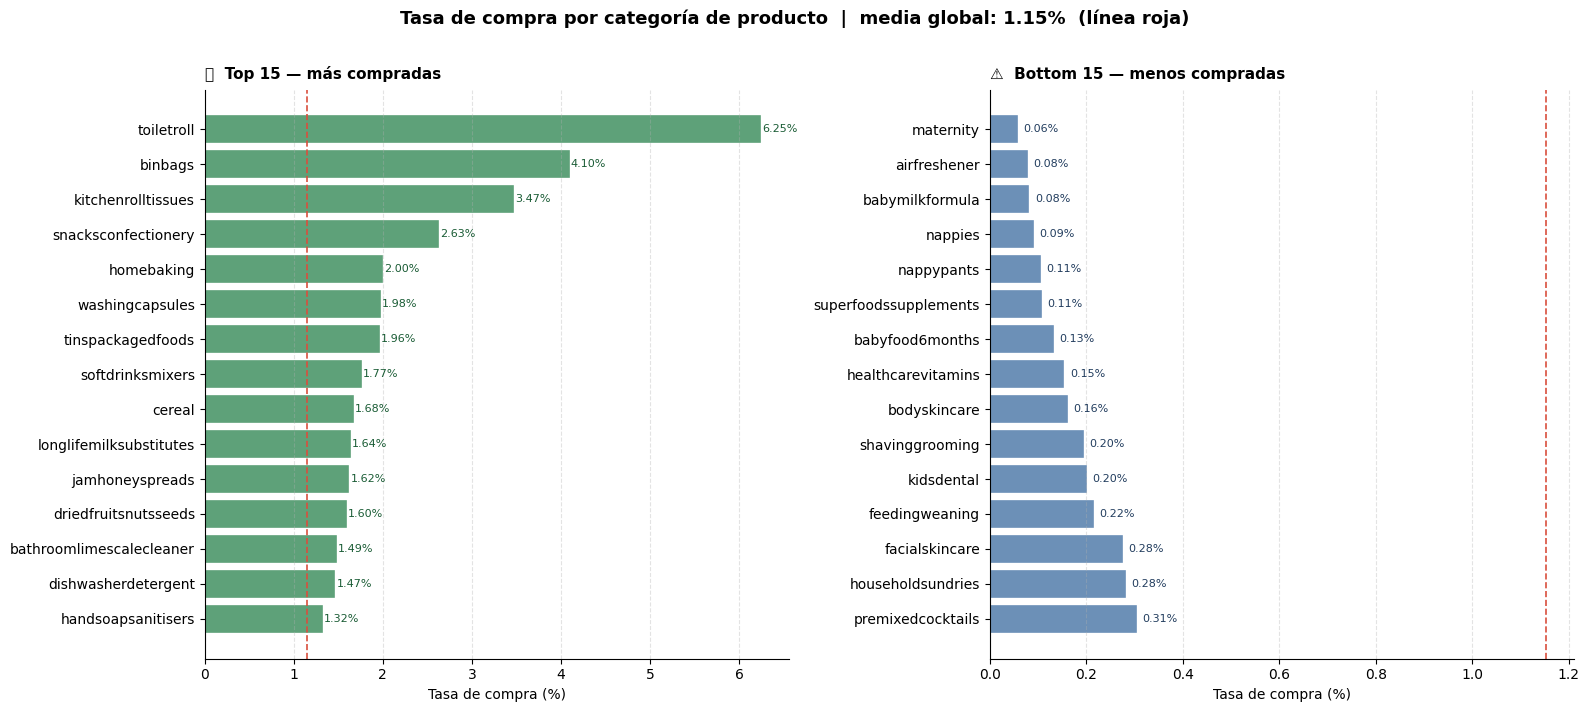

Plot saved.


In [7]:
# Side-by-side: top 15 (most purchased) and bottom 15 (least purchased)
top15_chart    = by_type_filtered.nlargest(15, "purchase_rate_pct").sort_values("purchase_rate_pct")
bottom15_chart = by_type_filtered.nsmallest(15, "purchase_rate_pct").sort_values("purchase_rate_pct", ascending=False)
overall_rate_pct = df["outcome"].mean() * 100

fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Tasa de compra por categoría de producto  |  media global: "
             f"{overall_rate_pct:.2f}%  (línea roja)",
             fontsize=13, fontweight="bold", y=1.01)

# Helper to draw one panel
def draw_panel(ax, data, title, col_bar, col_label):
    bars = ax.barh(data["product_type"], data["purchase_rate_pct"],
                   color=col_bar, alpha=0.82, edgecolor="white", linewidth=0.3)
    ax.axvline(overall_rate_pct, color="#D94F3D", linestyle="--", linewidth=1.2)
    for bar, val in zip(bars, data["purchase_rate_pct"]):
        ax.text(val + overall_rate_pct * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", fontsize=8, color=col_label)
    ax.set_xlabel("Tasa de compra (%)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

draw_panel(ax_top, top15_chart,
           "✅  Top 15 — más compradas", "#3A8C5C", "#1a5c35")
draw_panel(ax_bot, bottom15_chart,
           "⚠️  Bottom 15 — menos compradas", "#4C78A8", "#223d5e")

plt.tight_layout()
plt.savefig("product_type_rates.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved.")


### Conclusiones categorías de producto

La dispersión entre categorías es enorme: desde 6.25% de tasa de compra en `toiletroll` hasta 0.06% en `maternity`, una diferencia de 100x entre la categoría más y menos comprada.

Las más compradas son productos de consumo doméstico rutinario: papel de váter, bolsas de basura, papel de cocina. Son cosas que todo el mundo necesita y repone periódicamente. El modelo aprende bien porque la señal es muy consistente: si alguien compra papel de váter, lo va a volver a necesitar.

Las menos compradas también tienen mucho sentido: `maternity` (0.06%), `babymilkformula` (0.08%), `nappies` (0.09%). Estos productos son muy específicos de un momento de la vida concreto: si el bebé crece o el embarazo termina, la compra se detiene. El modelo prácticamente no puede aprender nada útil de estas categorías con los datos que tiene.

Algo curioso: `tinspackagedfoods` (comida en lata/envasada) aparece 226.474 veces. Es con diferencia la categoría más grande del catálogo en volumen, pero su tasa de compra es solo 1.96%. Tiene mucho volumen pero poca conversión. Son productos que se ofrecen constantemente pero que cada usuario compra de forma más selectiva.

## 6. ¿Compran diferente los usuarios nuevos y los viejos?

La columna `user_order_seq` nos dice si es el primero, segundo, tercer... pedido de ese usuario

Mi hipótesis es que los usuarios con más pedidos acumulados tienen un comportamiento más predecible: ya saben lo que les gusta, tienen productos marcados como regulares, y el modelo tiene más datos de ellos. Los usuarios en su primer o segundo pedido son casi una caja negra para el sistema.


In [8]:
# Purchase rate and binary feature activation by user_order_seq
by_seq = (
    df.groupby("user_order_seq")
    .agg(
        n_orders        =("order_id",         "nunique"),
        n_rows          =("outcome",           "count"),
        purchase_rate   =("outcome",           "mean"),
        pct_ordered_before  =("ordered_before",    "mean"),
        pct_set_as_regular  =("set_as_regular",    "mean"),
        pct_abandoned_before=("abandoned_before",  "mean"),
    )
    .reset_index()
)
by_seq["purchase_rate_pct"] = by_seq["purchase_rate"] * 100

print("=== PURCHASE BEHAVIOUR BY ORDER SEQUENCE ===\n")
print(f"  {'Seq':>4}  {'Orders':>7}  {'Purchase rate':>14}  "
      f"{'ordered_before':>15}  {'set_as_regular':>15}  {'abandoned_before':>17}")
print("  " + "-" * 85)
for _, row in by_seq.iterrows():
    print(f"  {int(row.user_order_seq):>4}  {int(row.n_orders):>7,}  "
          f"{row.purchase_rate_pct:>13.2f}%  "
          f"{row.pct_ordered_before:>14.1%}  "
          f"{row.pct_set_as_regular:>14.1%}  "
          f"{row.pct_abandoned_before:>16.1%}")


=== PURCHASE BEHAVIOUR BY ORDER SEQUENCE ===



   Seq   Orders   Purchase rate   ordered_before   set_as_regular   abandoned_before
  -------------------------------------------------------------------------------------
     2    1,712           1.08%            1.1%            0.2%              0.1%
     3      760           1.13%            1.9%            0.3%              0.0%
     4      403           1.23%            2.7%            0.4%              0.1%
     5      214           1.22%            3.4%            0.5%              0.0%
     6      130           1.32%            4.1%            0.6%              0.0%
     7       72           1.35%            5.1%            0.7%              0.0%
     8       45           1.71%            6.3%            1.2%              0.1%
     9       28           1.56%            7.3%            1.8%              0.0%
    10       19           1.48%            7.5%            0.7%              0.0%
    11       13           1.58%            9.1%            0.5%              0.0%
    12

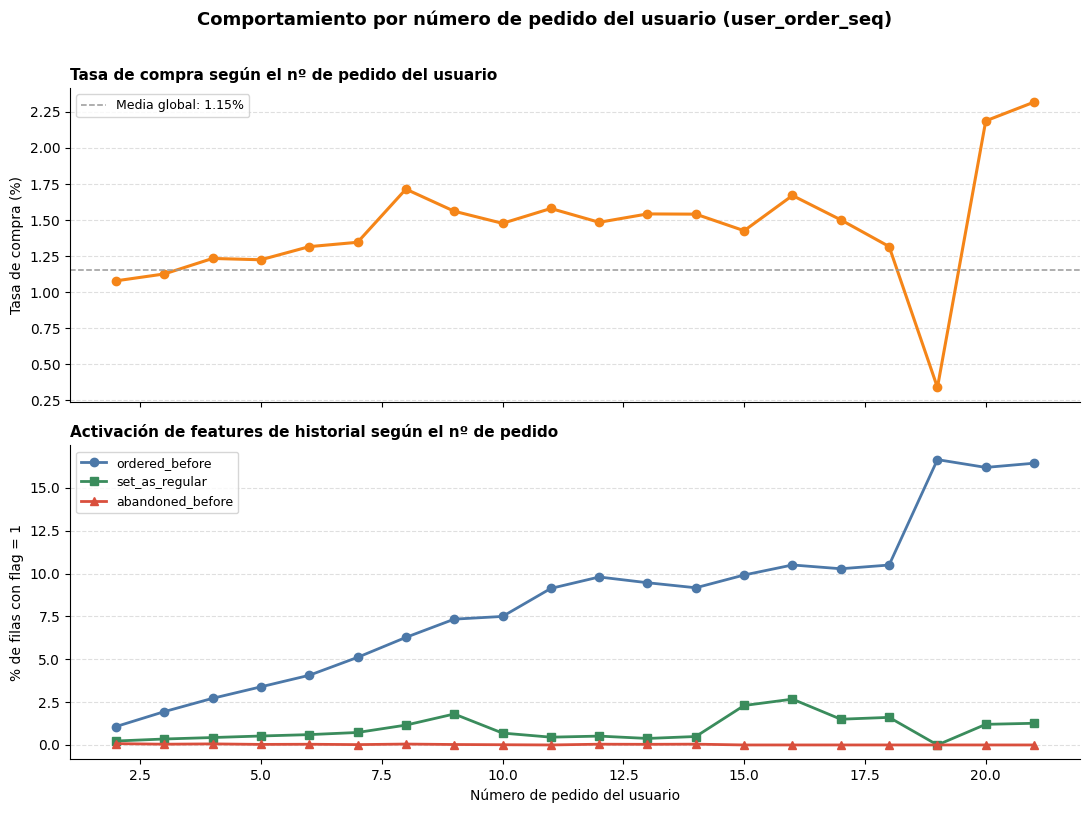

Plot saved.


In [9]:
# Visual: purchase rate and feature activation by order sequence
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle("Comportamiento por número de pedido del usuario (user_order_seq)",
             fontsize=13, fontweight="bold", y=1.01)

seq = by_seq["user_order_seq"]

#Panel 1: purchase rate
ax1.plot(seq, by_seq["purchase_rate_pct"],
         color="#F58518", marker="o", linewidth=2.2, markersize=6)
ax1.axhline(df["outcome"].mean() * 100, color="#999", linestyle="--",
            linewidth=1.1, label=f"Media global: {df['outcome'].mean()*100:.2f}%")
ax1.set_ylabel("Tasa de compra (%)", fontsize=10)
ax1.set_title("Tasa de compra según el nº de pedido del usuario",
              fontsize=11, fontweight="bold", loc="left")
ax1.legend(fontsize=9)

#Panel 2: % of rows where key binary features are active 
ax2.plot(seq, by_seq["pct_ordered_before"]   * 100, label="ordered_before",
         color="#4C78A8", marker="o", linewidth=2)
ax2.plot(seq, by_seq["pct_set_as_regular"]   * 100, label="set_as_regular",
         color="#3A8C5C", marker="s", linewidth=2)
ax2.plot(seq, by_seq["pct_abandoned_before"] * 100, label="abandoned_before",
         color="#D94F3D", marker="^", linewidth=2)
ax2.set_ylabel("% de filas con flag = 1", fontsize=10)
ax2.set_xlabel("Número de pedido del usuario", fontsize=10)
ax2.set_title("Activación de features de historial según el nº de pedido",
              fontsize=11, fontweight="bold", loc="left")
ax2.legend(fontsize=9)

for ax in (ax1, ax2):
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("user_order_seq.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved.")


In [10]:
# the anomalous dip at seq=19?
print("=== Sample size by user_order_seq (seq >= 15) ===\n")
high_seq = df[df["user_order_seq"] >= 15].copy()
size_check = (
    high_seq.groupby("user_order_seq")
    .agg(
        n_orders        =("order_id",  "nunique"),
        n_users         =("user_id",   "nunique"),
        n_rows          =("outcome",    "count"),
        purchase_rate   =("outcome",    "mean"),
        pct_ordered_before=("ordered_before", "mean"),
    )
    .reset_index()
)
size_check["purchase_rate_pct"] = (size_check["purchase_rate"] * 100).round(2)
print(size_check[["user_order_seq","n_orders","n_users","n_rows","purchase_rate_pct","pct_ordered_before"]].to_string(index=False))

# Zoom in on seq=19 specifically
print("\n=== Zoom on seq=19: who is this user? ===\n")
u19 = df[df["user_order_seq"] == 19]
order_id_19 = u19["order_id"].unique()[0]
print(f"  user_id         : {u19['user_id'].unique()[0]}")
print(f"  order_id        : {order_id_19}")
print(f"  candidate rows  : {len(u19)}")
print(f"  products bought : {int(u19['outcome'].sum())}  → {u19['outcome'].mean()*100:.2f}% purchase rate")
print(f"  ordered_before=1: {int(u19['ordered_before'].sum())} products  → {u19['ordered_before'].mean()*100:.1f}%")
print()
print("  → 1 order, 1 user. The stats are pure noise. Can't generalise from N=1.")


=== Sample size by user_order_seq (seq >= 15) ===

 user_order_seq  n_orders  n_users  n_rows  purchase_rate_pct  pct_ordered_before
             15         7        7    5819             1.4300              0.0992
             16         5        5    4190             1.6700              0.1050
             17         3        3    2597             1.5000              0.1028
             18         3        3    2734             1.3200              0.1050
             19         1        1     883             0.3400              0.1665
             20         1        1     914             2.1900              0.1619
             21         1        1     949             2.3200              0.1644

=== Zoom on seq=19: who is this user? ===

  user_id         : 3437823688836
  order_id        : 2918810910852
  candidate rows  : 883
  products bought : 3  → 0.34% purchase rate
  ordered_before=1: 147 products  → 16.6%

  → 1 order, 1 user. The stats are pure noise. Can't generalise from 

### Conclusiones comportamiento por pedido

Hay algo que llama la atención:`user_order_seq` empieza en 2, no en 1. Los usuarios en su primer pedido no aparecen en el dataset. Si es tu primer pedido, no hay ningún historial previo con el que construir las features, así que esas filas probablemente se descartaron al generar el dataset de ML.

Tasa de compra: Sube de 1.08% en el segundo pedido a 1.71% en el octavo. La progresión es gradual, no un salto brusco. A partir de seq=10 los datos son muy ruidosos, hay muy pocos pedidos (< 20 por grupo) y los porcentajes varían mucho.

Activación de features de historial: `ordered_before` pasa de 1.1% (seq=2) a ~10% (seq=10+). Con cada pedido el usuario acumula más productos con historial. `set_as_regular` crece más lento y `abandoned_before` se mantiene muy bajo en todos los grupos.

---

¿Qué pasa con el pico de seq=19? La gráfica muestra una caída a 0.34% justo cuando `ordered_before` está en su máximo (~16.6%). Si tiene tanto historial, ¿por qué compra tan poco?

La respuesta: seq=19 corresponde a un único usuario con un único pedido (883 productos ofrecidos). De esos, 147 tenían `ordered_before=1` (este usuario veterano ya había comprado 147 productos distintos antes). Pero en ese pedido concreto solo compró 3 cosas. Probablemente era un pedido de reposición muy pequeña, porque tenía la despensa casi llena.
La tendencia real está en seq 2–10, donde hay masa crítica. A más historial, más señal para el modelo. Todo lo de seq ≥ 15 son usuarios individuales que no generalizan (podríamos agruparlos en un segmento "veteranos").


## 7. ¿Hay features redundantes entre sí?

Si dos features dicen básicamente lo mismo (por ejemplo, `ordered_before` y `set_as_regular`), el modelo aprenderá información duplicada, lo que no aporta nada y puede complicar la interpretación. 

Vamos a calcular la matriz de correlación entre todas las features numéricas y binarias del dataset, y ver: Qué pares de features están muy correlacionadas entre sí (posibles redundancias) y qué features correlacionan más con `outcome` (confirma lo que ya vimos en la sección 3).

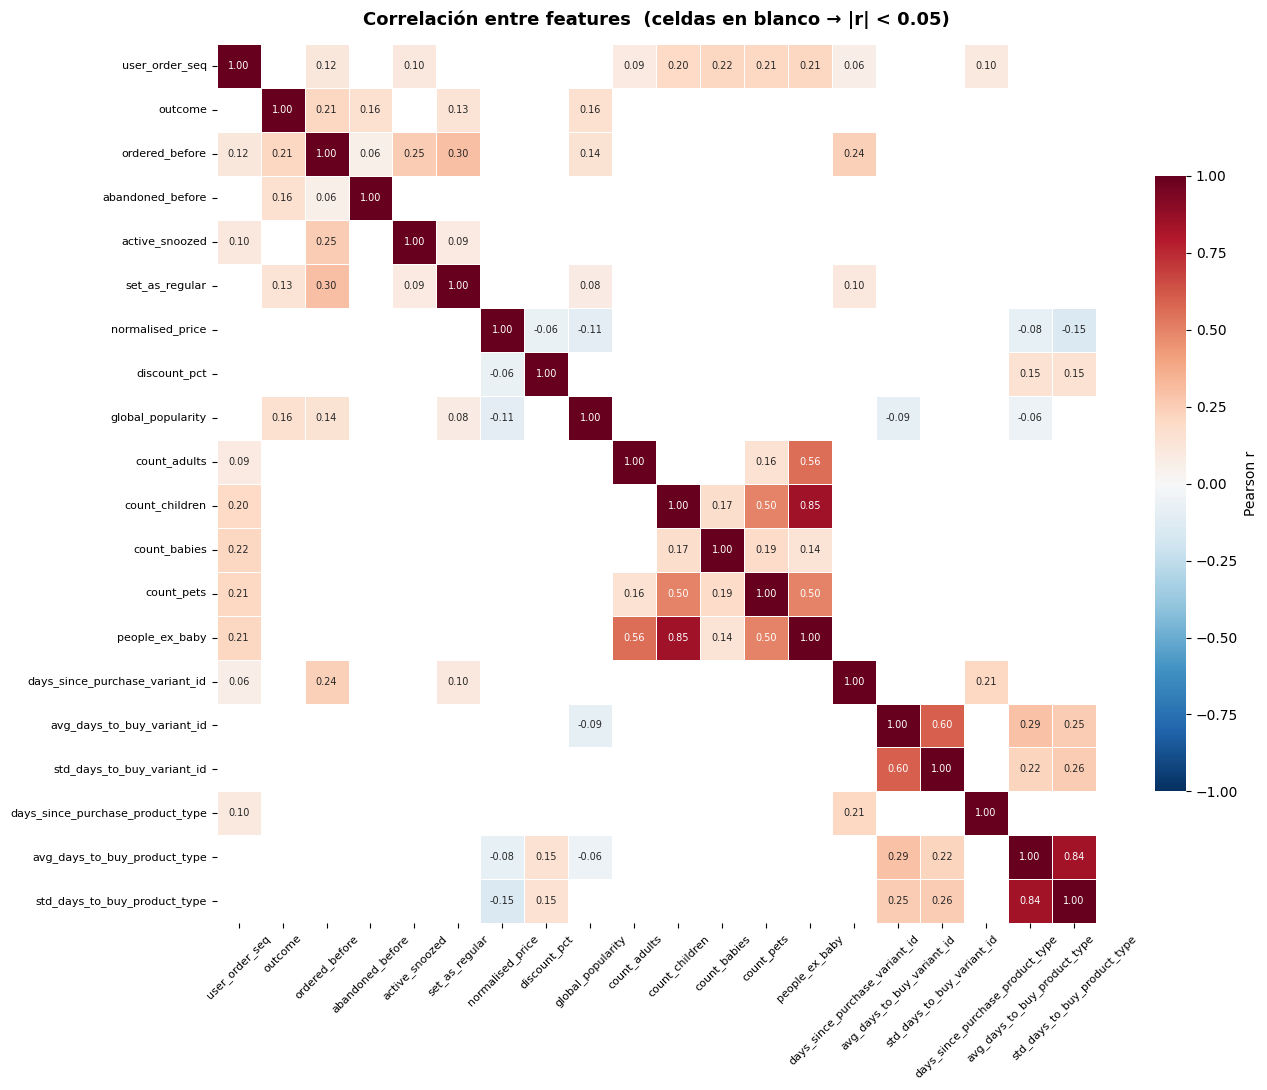

Heatmap saved.


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Keep only numeric columns
non_numeric = ["variant_id", "order_id", "user_id", "created_at", "order_date",
               "product_type", "vendor"]
feat_cols = [c for c in df.select_dtypes(include="number").columns if c not in non_numeric]

# Correlation matrix (Pearson)
corr = df[feat_cols].corr()

#Plot 1: full heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = corr.abs() < 0.05  

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.4,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
)
ax.set_title("Correlación entre features  (celdas en blanco → |r| < 0.05)",
             fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.tick_params(axis="y", labelsize=8, rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Heatmap saved.")


In [12]:
# Table 1: features ranked by their correlation with outcome 
print("=== Correlation with outcome (sorted by |r|) ===\n")
corr_with_outcome = (
    corr["outcome"]
    .drop("outcome")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
corr_with_outcome.columns = ["feature", "|r| with outcome"]
corr_with_outcome["r with outcome"] = corr["outcome"].drop("outcome").loc[corr_with_outcome["feature"]].values
print(corr_with_outcome[["feature", "r with outcome", "|r| with outcome"]].to_string(index=False))

# Table 2: pairs of features with high mutual correlation (possible redundancy)
print("\n=== Highly correlated feature pairs (|r| > 0.35, excluding outcome) ===\n")
feat_only = [c for c in feat_cols if c != "outcome"]
corr_feat = df[feat_only].corr()

pairs = []
for i, r in enumerate(feat_only):
    for j, c in enumerate(feat_only):
        if j <= i:
            continue
        val = corr_feat.loc[r, c]
        if abs(val) > 0.35:
            pairs.append((r, c, round(val, 3)))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if pairs:
    print(f"  {'Feature A':<30}  {'Feature B':<30}  {'r':>6}")
    print("  " + "-" * 70)
    for a, b, v in pairs:
        flag = "  ⚠️  HIGH" if abs(v) > 0.6 else ""
        print(f"  {a:<30}  {b:<30}  {v:>6.3f}{flag}")
else:
    print("  No pairs with |r| > 0.35 found.")


=== Correlation with outcome (sorted by |r|) ===

                         feature  r with outcome  |r| with outcome
                  ordered_before          0.2111            0.2111
                abandoned_before          0.1633            0.1633
               global_popularity          0.1626            0.1626
                  set_as_regular          0.1346            0.1346
                  active_snoozed          0.0458            0.0458
  days_since_purchase_variant_id          0.0228            0.0228
      avg_days_to_buy_variant_id         -0.0199            0.0199
                normalised_price         -0.0195            0.0195
    avg_days_to_buy_product_type         -0.0160            0.0160
    std_days_to_buy_product_type         -0.0117            0.0117
days_since_purchase_product_type          0.0105            0.0105
                  user_order_seq          0.0102            0.0102
      std_days_to_buy_variant_id         -0.0091            0.0091
            

  Feature A                       Feature B                            r
  ----------------------------------------------------------------------
  count_children                  people_ex_baby                   0.847  ⚠️  HIGH
  avg_days_to_buy_product_type    std_days_to_buy_product_type     0.840  ⚠️  HIGH
  avg_days_to_buy_variant_id      std_days_to_buy_variant_id       0.600
  count_adults                    people_ex_baby                   0.557
  count_children                  count_pets                       0.500
  count_pets                      people_ex_baby                   0.498


### Conclusiones correlación entre features
¿Qué correlaciona con `outcome`?: Solo 4 features tienen una correlación lineal mínimamente relevante con la variable:

| Feature | r con outcome | Interpretación |
|---|---|---|
| `ordered_before` | +0.21 | El más predictivo, como ya sabíamos |
| `abandoned_before` | +0.16 | Interés previo, aunque no se haya comprado |
| `global_popularity` | +0.16 | Productos populares → más probabilidad de compra |
| `set_as_regular` | +0.13 | Marcado como habitual → señal fuerte |

El resto de features tiene correlaciones prácticamente nulas (< 0.05). Esto no significa que sean inútiles. La correlación de Pearson mide relaciones lineales, y otro modelo puede capturar patrones no lineales que aquí no vemos.

Algo que me llama la atención: `discount_pct` tiene r = 0.001: el descuento prácticamente no correlaciona con la compra. Normalmente esperaríamos que a mayor descuento, mayor compra, pero los datos no lo confirman de forma lineal.

---

¿Hay features redundantes?

Sí, hay dos grupos claros de redundancia:

- Grupo 1: Household (hogar): `count_children`, `count_adults`, `people_ex_baby` y `count_pets` están correlacionadas entre sí (r entre 0.50 y 0.85). Tiene sentido: `people_ex_baby` se construye sumando adultos y niños, así que es casi como un duplicado. Además, estas features tienen correlación casi nula con `outcome`, así que aportan poco y se solapan entre sí.

- Grupo 2: Timing de compra: Los pares `avg_days_to_buy_* ↔ std_days_to_buy_*` están muy correlacionados (r ≈ 0.60–0.84), tanto a nivel de variante como de tipo de producto. La media y la desviación típica de los días entre compras suelen crecer juntas: si compras algo cada 60 días de media, la variabilidad también tiende a ser alta. A lo mejor podría ser suficiente con quedarse con la media y descartar la desviación.


---

## Conclusión global del EDA

Después de analizar el dataset `feature_frame.csv` desde todos los ángulos, aquí está el resumen de lo que sé antes de tocar un modelo.

---

### El dataset

Es un dataset de recomendación de productos de supermercado, con ~2.8 millones de filas donde cada fila representa la decisión de si un usuario compró o no un producto concreto dentro de un pedido. El 98.85% de las filas son "no compra": el desbalance de clases es grande y es el primer reto que habrá que gestionar al modelar.

---

### ¿Qué features importan?

El análisis tiene un ranking claro:

| # | Feature | Señal | Por qué |
|---|---|---|---|
| 1st | `ordered_before` | Muy alta | Lift de 20x. Si ya compraste este producto, probablemente lo vuelves a comprar |
| 2nd | `abandoned_before` | Alta | Lift de 7x. Si lo dejaste en el carrito, algo te interesaba |
| 3rd | `global_popularity` | Alta | r = 0.16. Los productos populares se compran más |
| 4th | `set_as_regular` | Notable | Lift de ~11x. Intención explícita del usuario |
| 5th | `normalised_price` | Moderada | Los productos comprados tienden a ser más baratos |
| ↓ | `discount_pct`, features de hogar, timing | Muy baja | r < 0.05 con outcome |

El historial personal del usuario domina sobre todo lo demás. No importa tanto si el producto es barato o popular en general, lo que de verdad predice la compra es si tú ya lo has comprado o te ha llamado la atención antes. Esto tiene sentido para un supermercado online: la gente tiende a repetir la cesta de la compra semana a semana.

---

### Riesgos y cosas a tener en cuenta

**1. Desbalance de clases**
Solo el 1.15% de las filas son compras reales. Un modelo que prediga siempre "no compra" tendría un 98.85% de accuracy (inútil?). Habrá que usar métricas apropiadas y técnicas de balanceo para que el modelo aprenda algo.

**2. Posible data leakage**
Features como `ordered_before` o `set_as_regular` se calculan a partir del historial previo del usuario, que eso está bien. Pero hay que asegurarse de que no contienen información del pedido actual al que pertenecen. Si se construyeron mal (incluyendo el pedido que queremos predecir), el modelo aprenderá a hacer "trampa".

**3. Features redundantes**
Hay dos grupos de variables que se solapan:
- **Household:** `count_children`, `count_adults`, `people_ex_baby`, y además no aportan. Candidatas a eliminar.
- **Timing:** `avg/std_days_to_buy` a nivel variante y tipo de producto, media y std van siempre juntas. Podría quedarse solo con la media.

**4. Ventana temporal corta**
Solo tenemos 6 meses de datos (oct 2020 – mar 2021). Es suficiente para entrenar algo, pero el modelo podría no generalizar bien a cambios estacionales más allá de ese periodo.

**5. Usuarios con poco historial (seq=2)**
Los usuarios en su segundo pedido tienen `ordered_before` casi al 0%, prácticamente sin señal. El modelo puede ser muy impreciso para clientes nuevos. Habría que considerar si a lo mejor tiene sentido tratarlos de forma diferente.